In [37]:
import os
import h5py
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [38]:
data_dir = "data/hydrogen"
data_files = os.listdir(data_dir)
energy_files = [f for f in data_files if "ener" in f]
print(f"Read {len(energy_files)} files.")

Read 3 files.


In [39]:
ccsd_energy = -1.14

In [40]:
bond_dims = []
dmrg_energies = []
krylov_energies = []
for energy_file in energy_files:
    print(f"Reading {energy_file}.")
    f = h5py.File(data_dir + "/" + energy_file, "r")
    energies = np.array(f["energies"])
    input_filename = str(np.array(f["input_filename"][()]).astype('T'))
    f.close()
    krylov_energies.append(energies)
    with open(input_filename, "rb") as f:
        input_dict = pickle.load(f)
    bond_dims.append(input_dict["input"]["chi_dmrg"])
    dmrg_energies.append(input_dict["dmrg_energy"])

Reading energies_2.hdf5.
Reading energies_0.hdf5.
Reading energies_1.hdf5.


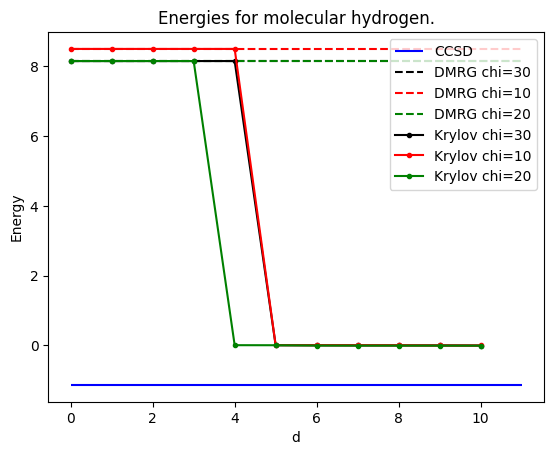

In [41]:
fig, ax = plt.subplots()

colors = ["k", "r", "g"]
assert len(colors) == len(bond_dims)

ax.hlines(ccsd_energy, 0, len(krylov_energies[0]), linestyle='-', label=f"CCSD", color='b')

for i, (chi, energy) in enumerate(zip(bond_dims, dmrg_energies)):
    ax.hlines(energy, 0, len(krylov_energies[0]), linestyle='--', label=f"DMRG chi={chi}", color=colors[i])

for i, energies in enumerate(krylov_energies):
    ax.plot(range(len(energies)), energies, '.-', color=colors[i], label=f"Krylov chi={bond_dims[i]}")

plt.legend()
ax.set_xlabel("d")
ax.set_ylabel("Energy")
ax.set_title("Energies for molecular hydrogen.")

plt.savefig("hydrogen_energies.pdf")